 # Lab 03 - Noise Removal and Structure Preservation

#### E/21/087 - Dewagedara D.M.E.S.

### Task 01 - Simulate Salt-and-Pepper Noise

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

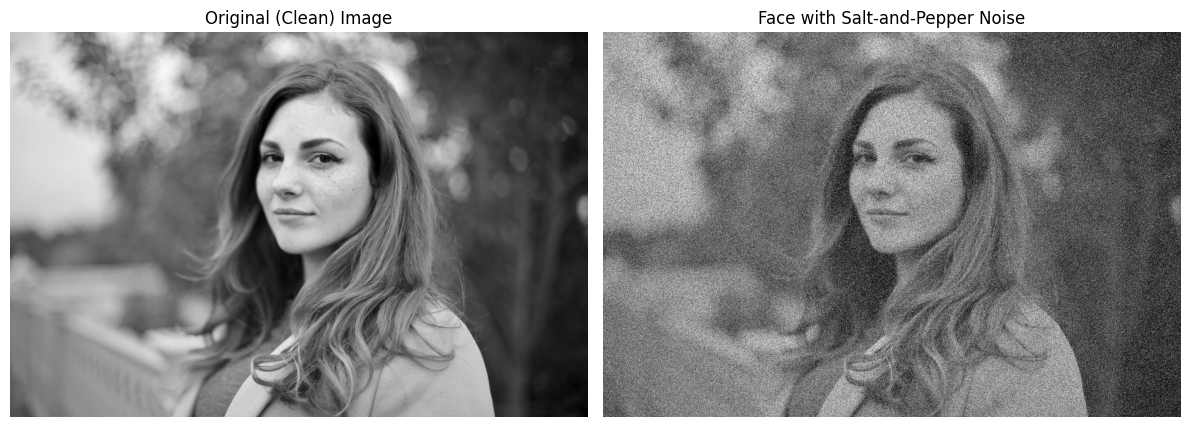

In [6]:
img = cv2.imread('face.jpg',0)

noisy = img.copy()
prob=0.2
noisy[np.random.rand(*img.shape) < prob] = 255

noisy[np.random.rand(*img.shape) < prob] = 0

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original (Clean) Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy, cmap='gray')
plt.title("Face with Salt-and-Pepper Noise")
plt.axis('off')
plt.tight_layout()
plt.show()

#### Answer -

##### Effect of Syntheric  Salt-and-Pepper Noise on a Face Image

Salt-and-pepper noise inserts random black and white pixels into the image, creating abrupt intensity changes. These sudden variations break smooth edges and textures of facial features such as eyes, lips, and skin shading. As a result, fine details are obscured and facial features appear distorted or unclear.


##### Why randomness breaks visual continuity:
Visual continuity depends on smooth and predictable changes between neighboring pixels. Random noise replaces correct pixel values with unrelated extreme values, destroying the natural relationship between pixels. This randomness breaks spatial coherence, making the image appear fragmented and disrupting the perception of continuous facial shapes and contours.


### Task 2 — Apply Mean Filter 

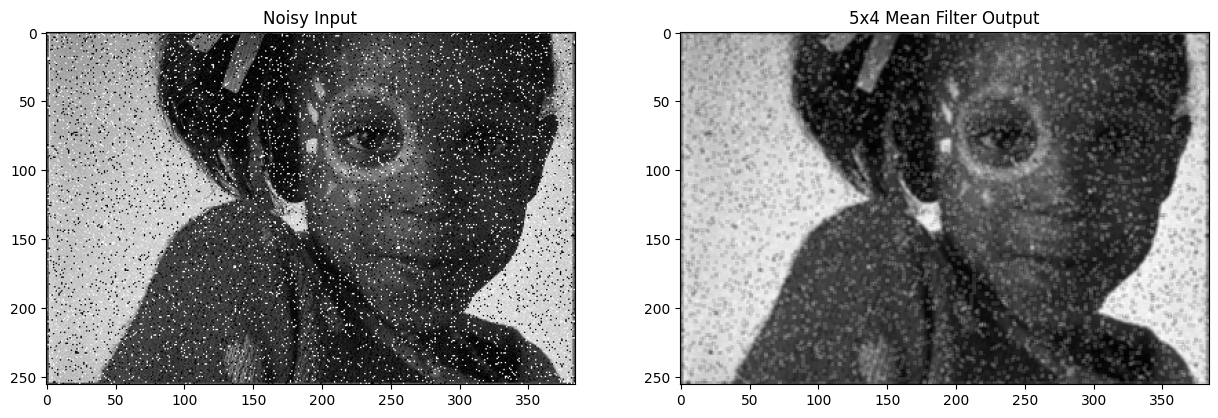

In [18]:
img = cv2.imread('Sample image.jpg', 0) 

noisy = img.copy()

mean_filtered = cv2.blur(noisy, (3, 3))

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.title("Noisy Input")
plt.imshow(noisy, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("5x4 Mean Filter Output")
plt.imshow(mean_filtered, cmap='gray')
plt.show()

#### Answer -

##### 1. Why the Image Becomes Blurry
A simple average filter works by replacing each pixel value with the mean of its neighboring pixels. While this reduces random noise by smoothing intensity variations, it also smooths genuine image details. Since edges and fine structures are composed of sharp intensity changes, averaging spreads these changes over neighboring pixels, making transitions more gradual and causing the image to appear blurry.
##### 2.Why Naive Smoothing Destroys Edge Sharpness

Naive smoothing does not distinguish between noise and important image features like edges. At edges, pixel neighborhoods contain values from both sides of a boundary. The averaging process mixes these values, reducing contrast across the edge and shifting edge locations. As a result, edges lose their sharpness and appear thick or faded, leading to loss of important structural information.

### Task 3 — Median Filter for Salt-Pepper 

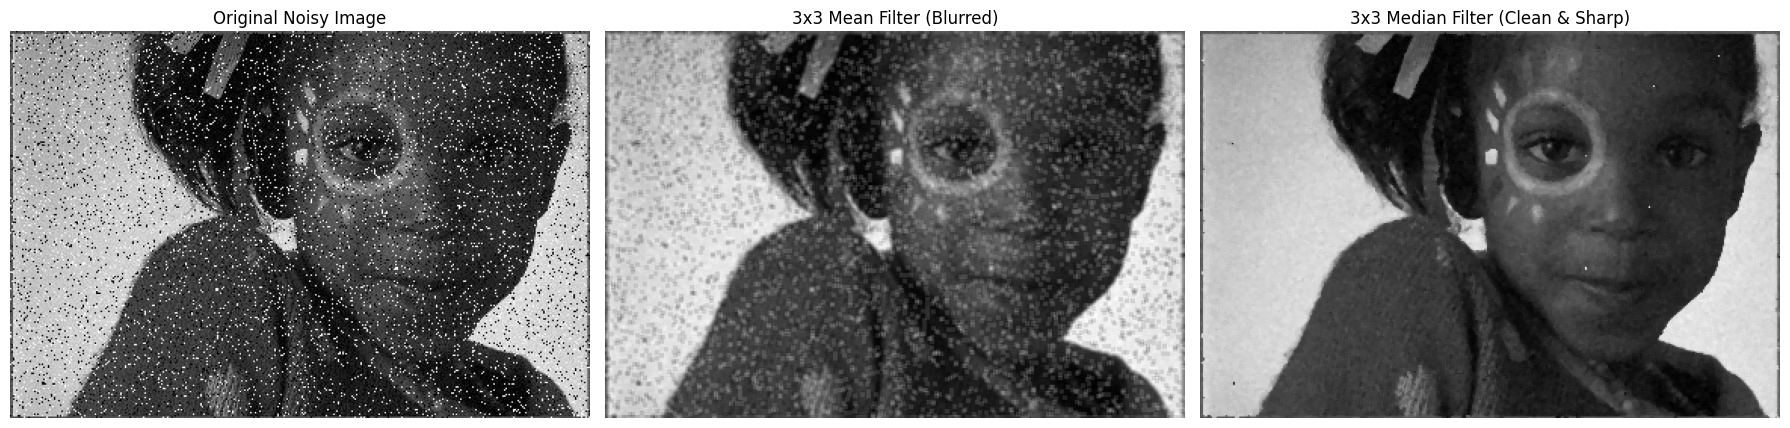

In [29]:

mean_result = cv2.blur(noisy,(3, 3))

median_result = cv2.medianBlur(noisy, 3)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(noisy, cmap='gray')
plt.title("Original Noisy Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mean_result, cmap='gray')
plt.title("3x3 Mean Filter (Blurred)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(median_result, cmap='gray')
plt.title("3x3 Median Filter (Clean & Sharp)")
plt.axis('off')

plt.tight_layout()
plt.show()

#### Answer -

##### Median Filter vs Mean Filter for Salt-and-Pepper Noise

When a median filter is applied to an image corrupted by salt-and-pepper noise, it removes most of the isolated black and white impulse pixels effectively. Unlike the mean (average) filter, which averages all pixel values in a neighborhood, the median filter replaces each pixel with the median value of its neighborhood. This makes it less sensitive to extreme outliers caused by impulse noise.

The median filter preserves edges better because it does not create new pixel values by averaging across intensity boundaries. At edges, the median value usually belongs to one side of the edge, so sharp transitions are maintained. In contrast, the mean filter smooths across edges, causing blurring and loss of edge sharpness.

Overall, the median filter is more effective than the mean filter for salt-and-pepper noise because it removes impulse noise while preserving important structural details and edges in the image.

### Task 4 — Gaussian Smoothing 

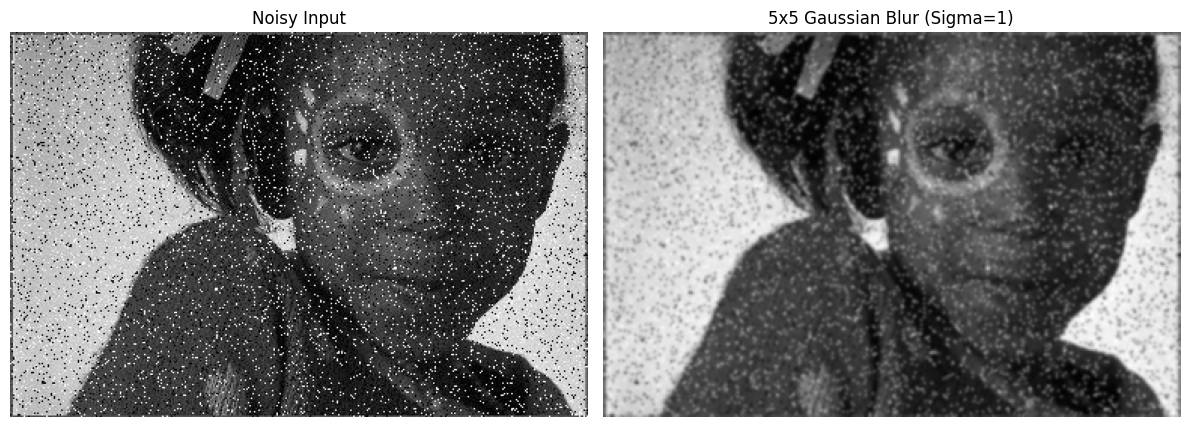

In [37]:
gauss_blur = cv2.GaussianBlur(noisy, (5, 5), 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Input")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gauss_blur, cmap='gray')
plt.title("5x5 Gaussian Blur (Sigma=1)")
plt.axis('off')

plt.tight_layout()
plt.show()

#### Answer - 

##### Noise Reduction vs Structural Loss

Gaussian blur smooths an image by replacing each pixel with a weighted average of its neighbors, where closer pixels have higher influence (Gaussian distribution). When applied to a noisy image, it effectively reduces Gaussian-type noise and small intensity fluctuations, producing a smoother and more visually pleasing result than simple averaging.

##### Trade-off explanation:

- Noise Reduction:
Gaussian blur suppresses high-frequency components of the image, which include random noise. As the kernel size or standard deviation (σ) increases, noise is reduced more effectively.

- Structural Loss:
Important image details such as edges, corners, and fine textures are also high-frequency components. Gaussian blur does not distinguish between noise and real structures, so edges become less sharp, facial features soften, and fine details are lost.


### Task 5 — Bilateral Filtering for Edge Preservation

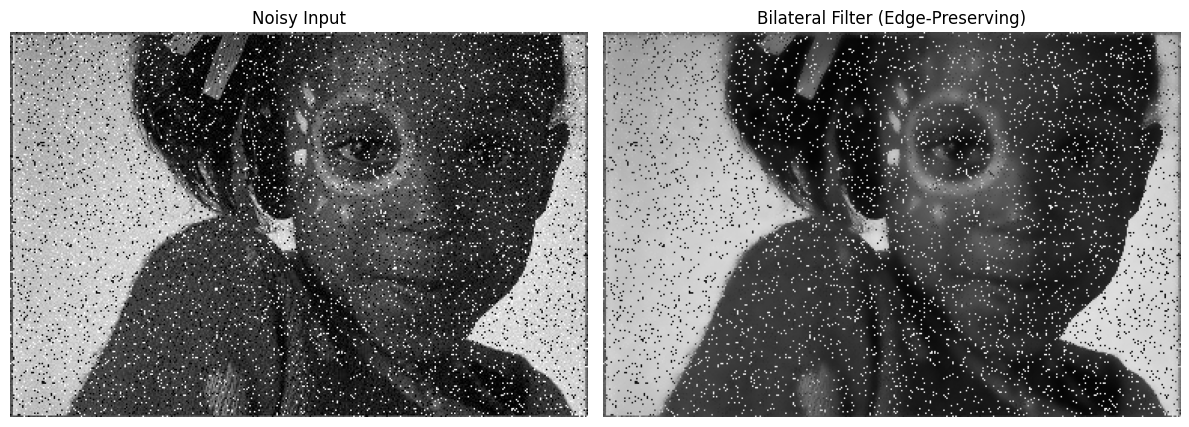

In [38]:
bilateral_result = cv2.bilateralFilter(noisy, 9, 60, 60)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Input")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bilateral_result, cmap='gray')
plt.title("Bilateral Filter (Edge-Preserving)")
plt.axis('off')

plt.tight_layout()
plt.show()

#### Answer -

##### Edge-Preserving Smoothing
The bilateral filter smooths noise while preserving edges by considering both spatial proximity and intensity similarity when averaging pixels. Unlike mean or Gaussian filters, it reduces noise only among pixels with similar intensity values, preventing smoothing across sharp intensity changes.

##### Why edges are preserved
At edges (such as boundaries of eyes, nose, lips, and face outline), neighboring pixels have large intensity differences. The bilateral filter assigns very low weights to pixels with dissimilar intensities, so averaging does not occur across the edge. This preserves edge discontinuities and keeps boundaries sharp.

##### Why preserving edges keeps facial identity intact
Facial identity depends heavily on the relative positions and shapes of key features and their edges. By maintaining sharp transitions at facial boundaries and feature contours, the bilateral filter retains important structural information while removing noise from smoother regions like skin. As a result, the face remains recognizable, with reduced noise and minimal loss of identity-defining details.

### Task 6 — Laplacian Sharpening 

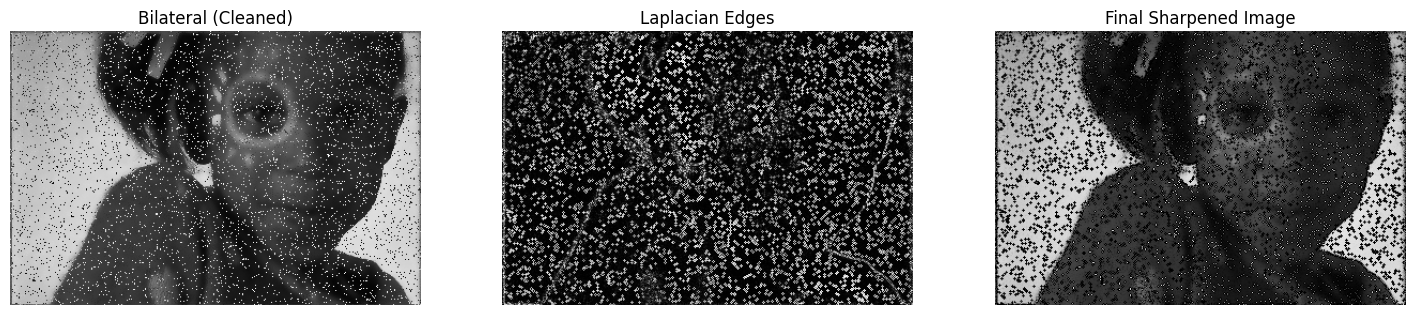

In [24]:

laplacian = cv2.Laplacian(bilateral_result, cv2.CV_64F)

laplacian_8bit = np.uint8(np.absolute(laplacian))

sharpened = cv2.subtract(bilateral_result, laplacian_8bit)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(bilateral_result, cmap='gray')
plt.title("Bilateral (Cleaned)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(laplacian_8bit, cmap='gray')
plt.title("Laplacian Edges")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharpened, cmap='gray')
plt.title("Final Sharpened Image")
plt.axis('off')

plt.show()

#### Answer -

##### Effects and Limitations
Laplacian sharpening enhances an image by emphasizing regions of rapid intensity change, which correspond to edges and structural boundaries such as facial contours, eyes, nose, and lips. By subtracting the Laplacian from the smoothed image, edges become more pronounced and fine details appear sharper.

##### Effect on structural boundaries:
The Laplacian operator highlights high-frequency components, strengthening edges and improving the visual clarity of important facial features. This makes the image look sharper and better defined after smoothing.

##### Risk of re-magnifying noise:
If sharpening is applied too strongly or on insufficiently denoised images, the Laplacian also amplifies residual noise, since noise is also a high-frequency component. This can introduce graininess and unwanted artifacts, reducing image quality.

#### Effects and Limitations

Laplacian sharpening enhances an image by emphasizing regions of rapid intensity change, which correspond to edges and structural boundaries such as facial contours, eyes, nose, and lips. By subtracting the Laplacian (second-order derivative) from the smoothed image, edges become more pronounced and fine details appear sharper.

#### Effect on structural boundaries:
The Laplacian operator highlights high-frequency components, strengthening edges and improving the visual clarity of important facial features. This makes the image look sharper and better defined after smoothing.

#### Risk of re-magnifying noise:
If sharpening is applied too strongly or on insufficiently denoised images, the Laplacian also amplifies residual noise, since noise is also a high-frequency component. This can introduce graininess and unwanted artifacts, reducing image quality.

### Final Reflection

The fundamental challenge in image restoration lies in the inverse relationship between noise suppression and structural integrity. Denoising aims to eliminate high-frequency outliers, but because meaningful details like edges, textures, and facial boundaries are also high-frequency signals, standard linear filters (like Mean and Gaussian) cannot distinguish between the two, leading to a loss of clarity. Among the methods tested, the Bilateral Filter produced the best compromise for the portrait image. While the Median Filter was the most effective at surgically removing salt-and-pepper impulses, the Bilateral Filter excelled at "content-aware" smoothing. By weighing pixels based on both spatial distance and intensity similarity, it effectively smoothed the skin's surface while preserving the sharp "discontinuities" of the facial features. This ensured that the person’s identity remained intact and the subsequent Laplacian sharpening could enhance the structure rather than re-magnifying suppressed noise.